In [2]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from data import get_y, get_dataloader
from config_mounir import FarOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite, performance_report
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

In [7]:
framework = FarOODFramework()
dataset_id, dataset_ood = framework.get_confs("id", "ash"), framework.get_confs("ood","ash")
X = np.vstack([dataset_id, dataset_ood])
Y = get_y(dataset_id, dataset_ood)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
# with open("data_vf.pkl", 'wb') as f:
#     pickle.dump(data, f)

# Chargement des données

In [8]:
with open('data_vf.pkl', 'rb') as f:
    data = pickle.load(f)
    
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=32) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=32) 

5652 elements (array([0., 1.], dtype=float32), array([ 674, 4978]))
1413 elements (array([0., 1.], dtype=float32), array([ 169, 1244]))


# Modèle 1 Couche

In [9]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(data["y_train"], return_counts=True) ### Entrainement avec pondération
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.13539574126155082

## Entrainement

cuda
accuracy train:  0.8809322034571804


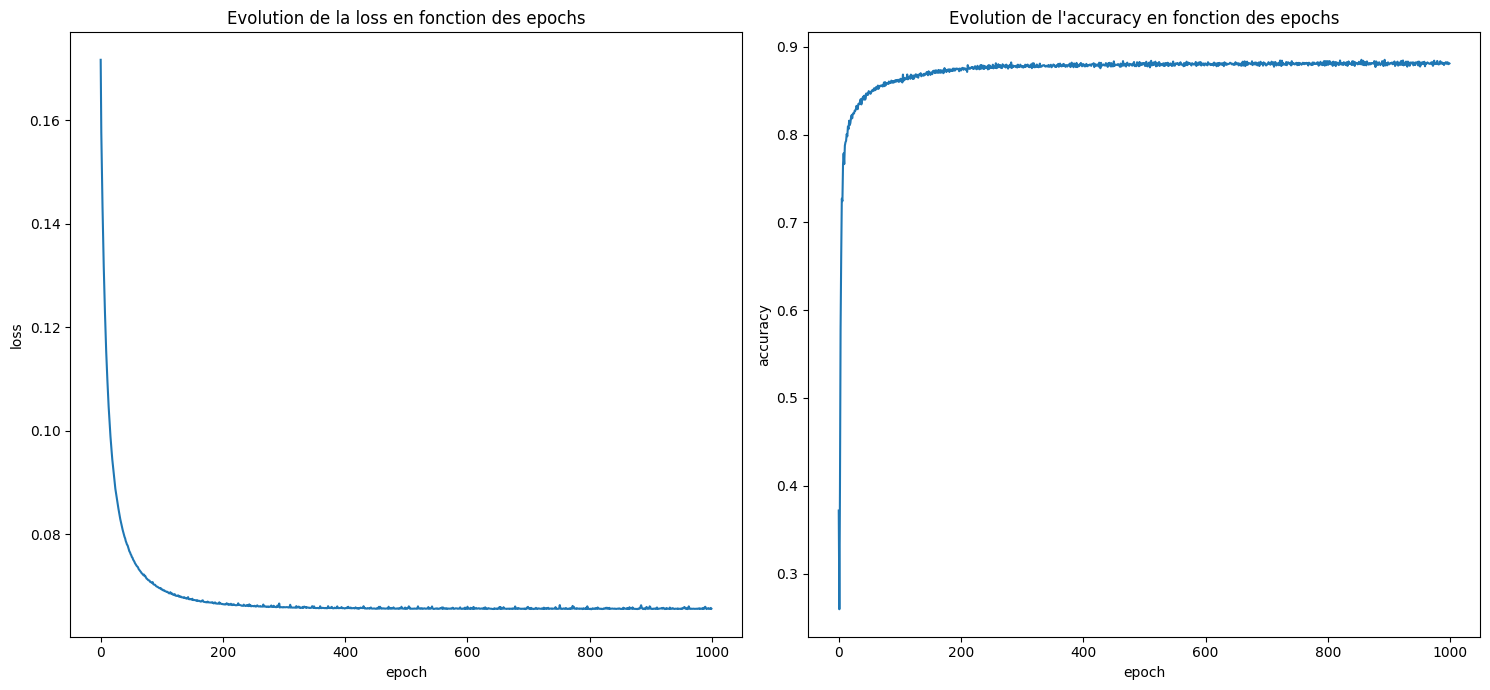

In [ ]:
nb_epochs = 1000
lr = 1e-1
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
torch.save(model.state_dict(), "model_vf.pth")

In [26]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-8.2436,  4.2558, -5.5319, -1.8816]])
bias
tensor([8.7740])


## Tests

In [13]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_vf.pth"))

<All keys matched successfully>

Accuracy test:  0.8804
Séparabilité:


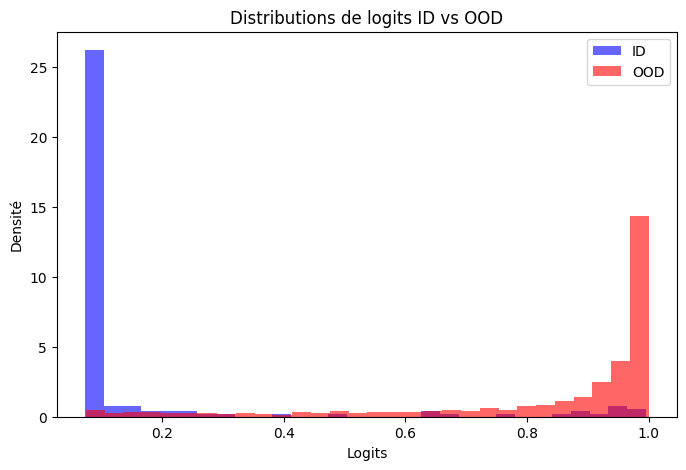

AUC ROC: 0.9569
FPR@TPR95: 0.1243

Correlation ID :  0.55707793243899
Correlation OOD :  0.8538221226623032


,config,tout,video,flow
0,poids_far_ood,3.9702,-5.7382,-2.0629
1,perturbation_far_ood_id,0.0089,0.0061,0.0025
2,perturbation_far_ood_ood,0.0299,0.0161,0.0132


In [14]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, FarOODFramework())

# Modèle 2 Couches

cpu
accuracy train:  0.932026836158192


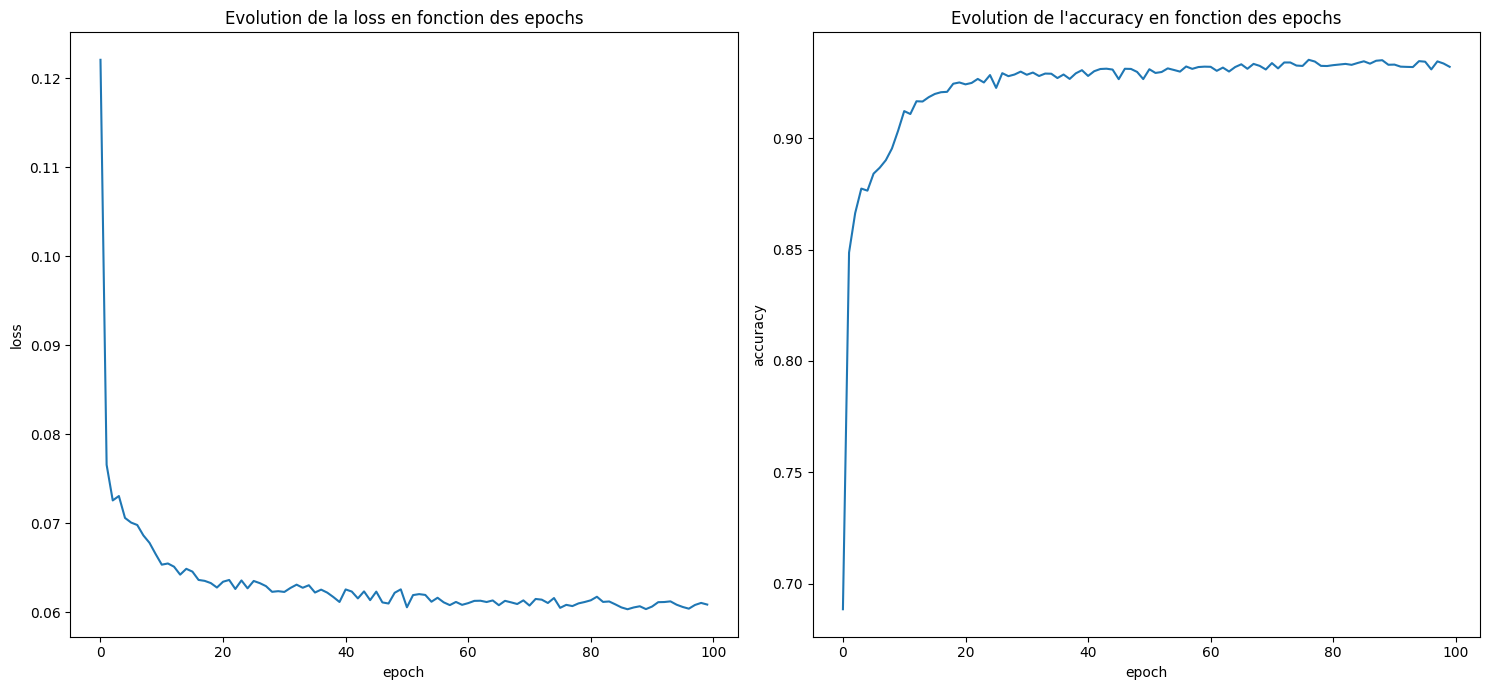

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 100

plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
torch.save(model.state_dict(), "model_vf_2c.pth") 

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_vf_2c.pth")) 

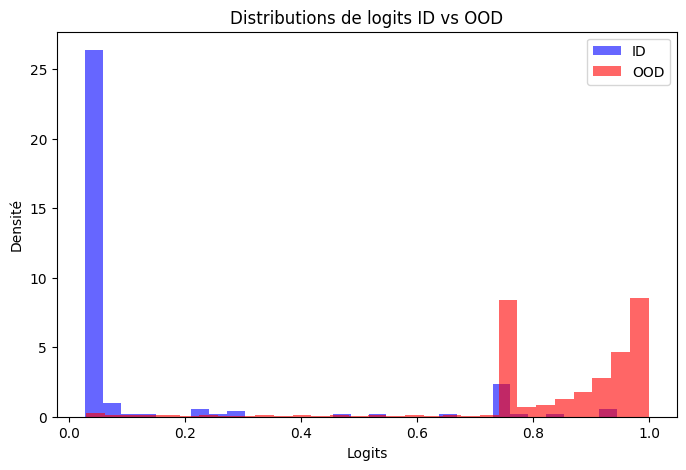

In [39]:
outputs_test = calc_outputs_test(model, test_dataloader)
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


In [40]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.9679645731463689, 0.11242603550295859)